<a href="https://colab.research.google.com/github/Anubhav-maurya6386/INTRANSHIP_TASK/blob/main/Level2Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Load Dataset

In [2]:
df = pd.read_csv("/content/churn-bigml-20.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


# Step 3: Data Preprocessing

In [3]:
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


# Encode Categorical Variables

In [5]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# Split Features & Target

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 4: Train Logistic Regression Model

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()


# Step 5: Predictions

In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Step 6: Evaluation Metrics

In [11]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.917910447761194


# Confusion Matrix

In [12]:
print(confusion_matrix(y_test, y_pred))

[[116   3]
 [  8   7]]


# Precision, Recall, F1-score

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.94      0.97      0.95       119
        True       0.70      0.47      0.56        15

    accuracy                           0.92       134
   macro avg       0.82      0.72      0.76       134
weighted avg       0.91      0.92      0.91       134



# Step 7: ROC Curve

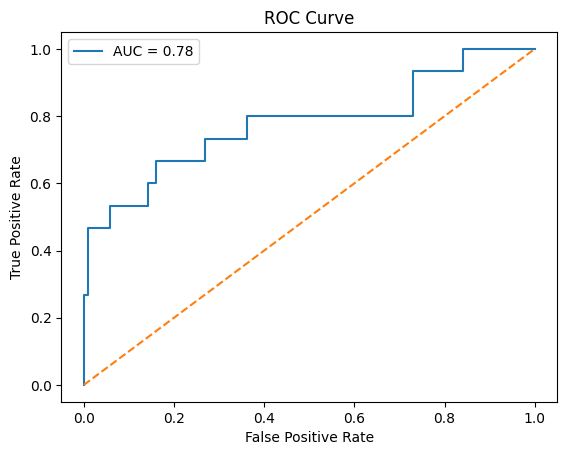

In [14]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()